<a href="https://colab.research.google.com/github/thegauravjoshi02/My-portfolio/blob/main/Another_copy_of_Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluation_parameters(y_test, y_pred):
    print("\n----- Evaluation Parameters -----\n")

    accuracy = accuracy_score(y_test, y_pred)
    precision_pos = precision_score(y_test, y_pred, pos_label=1)
    recall_pos = recall_score(y_test, y_pred, pos_label=1)
    f1_pos = f1_score(y_test, y_pred, pos_label=1)

    precision_neg = precision_score(y_test, y_pred, pos_label=0)
    recall_neg = recall_score(y_test, y_pred, pos_label=0)
    f1_neg = f1_score(y_test, y_pred, pos_label=0)

    # Print Table
    print(f"{'Metric':<15} {'Positive':<15} {'Negative':<15}")
    print("-"*45)
    print(f"{'Precision':<15} {precision_pos:<15.4f} {precision_neg:<15.4f}")
    print(f"{'Recall':<15} {recall_pos:<15.4f} {recall_neg:<15.4f}")
    print(f"{'F1-Score':<15} {f1_pos:<15.4f} {f1_neg:<15.4f}")
    print(f"\nOverall Accuracy: {accuracy:.4f}")

In [ ]:
import pandas as pd

df = pd.read_csv(
    "sentiment140.csv",
    encoding='latin-1',
    on_bad_lines='skip'
)

print("Dataset Loaded Successfully")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'sentiment140.csv'

In [ ]:
df.columns = ['sentiment','id','date','query','user','text']
df.head()

,sentiment,id,date,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1599999 non-null  int64 
 1   id         1599999 non-null  int64 
 2   date       1599999 non-null  object
 3   query      1599999 non-null  object
 4   user       1599999 non-null  object
 5   text       1599999 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [ ]:
df.shape

(1599999, 6)

In [ ]:
df.isnull().sum()

,0
0,0
1467810369,0
Mon Apr 06 22:19:45 PDT 2009,0
NO_QUERY,0
_TheSpecialOne_,0
"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.sample(100000, random_state=42)

In [ ]:
df['sentiment'] =df['sentiment'].replace(4,1)
df['sentiment'].value_counts()

,count
sentiment,
1,800000
0,799999


In [ ]:
df = df[['sentiment','text']]
df.head()
df['sentiment'].value_counts()

,count
sentiment,
4,800000
0,799999


In [ ]:
import re

df['text'] = df['text'].fillna('')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

X = df['clean_text']
y = df['sentiment']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
print(df['sentiment'].value_counts(normalize=True)*100)


df = df[["clean_text","sentiment"]]

X = df["clean_text"]
y = df["sentiment"]

print(X.head())
print(y.head())

sentiment
1    50.000031
0    49.999969
Name: proportion, dtype: float64
0    is upset that he cant update his facebook by t...
1    i dived many times for the ball managed to sav...
2       my whole body feels itchy and like its on fire
3    no its not behaving at all im mad why am i her...
4                                   not the whole crew
Name: clean_text, dtype: object
0    0
1    0
2    0
3    0
4    0
Name: sentiment, dtype: int64


In [ ]:
print(type(X))
print(type(y))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [ ]:
X.info()
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1599999 entries, 0 to 1599998
Series name: clean_text
Non-Null Count    Dtype 
--------------    ----- 
1599999 non-null  object
dtypes: object(1)
memory usage: 12.2+ MB
<class 'pandas.core.series.Series'>
RangeIndex: 1599999 entries, 0 to 1599998
Series name: sentiment
Non-Null Count    Dtype
--------------    -----
1599999 non-null  int64
dtypes: int64(1)
memory usage: 12.2 MB


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

print(X.shape)

(1599999, 5000)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
accuracies = {}
def get_accuracy(X_selected, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=0.2, random_state=42
    )

    model = MultinomialNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

    return acc

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1279999, 8905)
Test shape: (320000, 8905)


In [ ]:

chi_3000 = SelectKBest(chi2, k=3000)
X_3000 = chi_3000.fit_transform(X_tfidf, y)
accuracies['3000'] = get_accuracy(X_3000, y, "3000 Features")

3000 Features Accuracy: 0.7686


In [ ]:
chi_5000 = SelectKBest(chi2, k=5000)
X_5000 = chi_5000.fit_transform(X_tfidf, y)
accuracies['5000'] = get_accuracy(X_5000, y, "5000 Features")



5000 Features Accuracy: 0.7725


In [ ]:
chi_7000 = SelectKBest(chi2, k=7000)
X_7000 = chi_7000.fit_transform(X_tfidf, y)
accuracies['7000'] = get_accuracy(X_7000, y, "7000 Features")


7000 Features Accuracy: 0.7747


In [ ]:
result_df = pd.DataFrame({
    "Feature Size": accuracies.keys(),
    "Accuracy": accuracies.values()
})

print("\nFinal Comparison:\n")
print(result_df)


Final Comparison:

  Feature Size  Accuracy
0         3000  0.768613
1         5000  0.772497
2         7000  0.774678


In [ ]:
chi_001 = SelectFpr(score_func=chi2, alpha=0.01)
X_001 = chi_001.fit_transform(X_tfidf, y)
accuracies['alpha=0.01'] = get_accuracy(X_001, y, "Alpha 0.01")

chi_005 = SelectFpr(score_func=chi2, alpha=0.05)
X_005 = chi_005.fit_transform(X_tfidf, y)
accuracies['alpha=0.05'] = get_accuracy(X_005, y, "Alpha 0.05")

chi_05 = SelectFpr(score_func=chi2, alpha=0.5)
X_05 = chi_05.fit_transform(X_tfidf, y)
accuracies['alpha=0.5'] = get_accuracy(X_05, y, "Alpha 0.5")


Alpha 0.01 Accuracy: 0.7732
Alpha 0.05 Accuracy: 0.7761
Alpha 0.5 Accuracy: 0.7852


In [ ]:
result_df = pd.DataFrame({
    "Alpha Value": accuracies.keys(),
    "Accuracy": accuracies.values()
})

print("\nFinal Comparison:\n")
print(result_df)


Final Comparison:

  Alpha Value  Accuracy
0        3000  0.768613
1        5000  0.772497
2        7000  0.774678
3  alpha=0.01  0.773166
4  alpha=0.05  0.776081
5   alpha=0.5  0.785188


In [ ]:
def evaluate_model(X_data, y, name):

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y, test_size=0.2, random_state=42
    )

    model = MultinomialNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')

    return acc, f1


results = []


acc, f1 = evaluate_model(X_3000, y, "3000")
results.append(["3000", acc, f1])

acc, f1 = evaluate_model(X_5000, y, "5000")
results.append(["5000", acc, f1])

acc, f1 = evaluate_model(X_7000, y, "7000")
results.append(["7000", acc, f1])


for r in results:
    print(f"{r[0]} → Accuracy: {r[1]:.4f}, F1: {r[2]:.4f}")

best = max(results, key=lambda x: x[2])

print("\n Best Model:")
print(f"Features: {best[0]}")
print(f"Accuracy: {best[1]:.4f}")
print(f"F1 Score: {best[2]:.4f}")

3000 → Accuracy: 0.7686, F1: 0.7638
5000 → Accuracy: 0.7725, F1: 0.7688
7000 → Accuracy: 0.7747, F1: 0.7714

 Best Model:
Features: 7000
Accuracy: 0.7747
F1 Score: 0.7714


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_7000, y, test_size=0.2, random_state=42
)
model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.774678125

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.79      0.78    159494
           1       0.79      0.76      0.77    160506

    accuracy                           0.77    320000
   macro avg       0.78      0.77      0.77    320000
weighted avg       0.78      0.77      0.77    320000



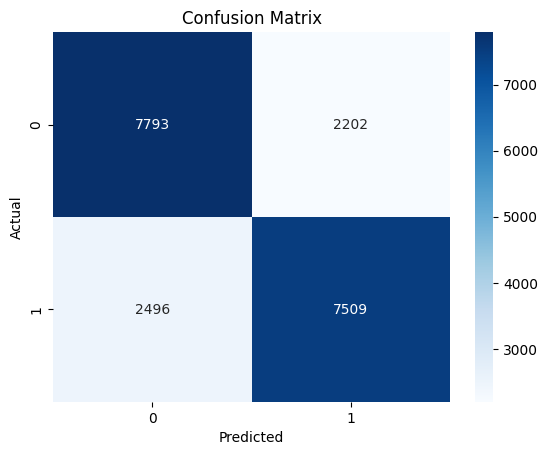

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc_normal = accuracy_score(y_test, y_pred)

print("\nWithout Chi-Square Accuracy:", acc_normal)



Without Chi-Square Accuracy: 0.774678125


In [ ]:
from sklearn.metrics import roc_auc_score
roc = roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_selected, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

ROC-AUC: 0.7760211186149162
Cross Validation Accuracy: 0.7738811072261164


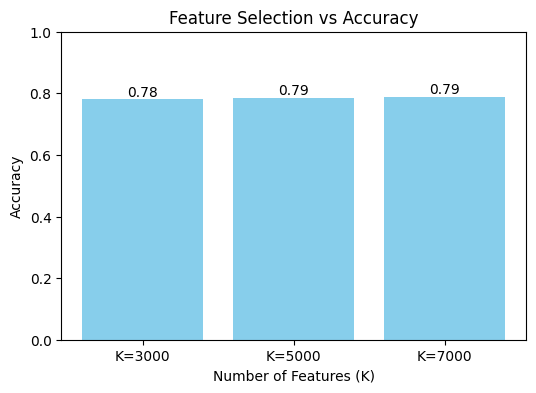

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results.keys(), results.values(), color='skyblue')

plt.title("Feature Selection vs Accuracy")
plt.xlabel("Number of Features (K)")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

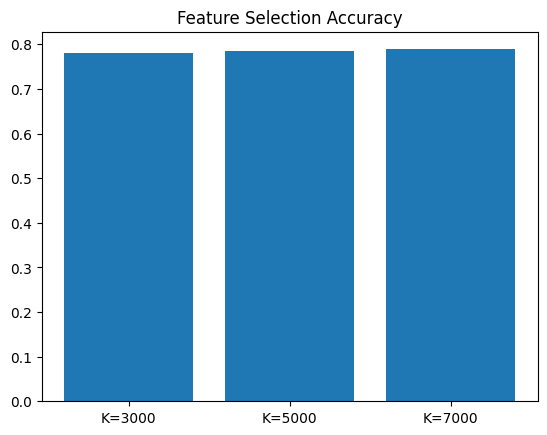

In [ ]:
plt.bar(results.keys(), results.values())
plt.title("Feature Selection Accuracy")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

texts = [
    "I love this", "Amazing product", "Very good",
    "I hate this", "Worst experience", "Very bad"
]

labels = [1,1,1, 0,0,0]

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(texts)

model = LogisticRegression()
model.fit(X, labels)

text = input("Enter text: ").lower()
X_input = vectorizer.transform([text])
pred = model.predict(X_input)[0]

print("Positive" if pred==1 else "Negative")

Enter text: I Love This
Positive


In [ ]:
import streamlit as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

texts = [
    "I love this movie", "This was fantastic", "Amazing experience",
    "Very good product", "Superb quality", "I am very happy",
    "I hate this movie", "Worst film ever", "Very bad experience",
    "Not good at all", "Terrible service", "Poor quality"
]

labels = [1,1,1,1,1,1, 0,0,0,0,0,0]

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(texts)

nb_model = MultinomialNB()
lr_model = LogisticRegression()
svm_model = LinearSVC()

nb_model.fit(X, labels)
lr_model.fit(X, labels)
svm_model.fit(X, labels)

st.title("Sentiment Analysis Dashboard (Best Models)")

model_choice = st.selectbox(
    "Choose Model:",
    ["Naive Bayes", "Logistic Regression", "SVM"]
)

user_input = st.text_area("Enter your text:")

if st.button("Predict"):
    if user_input:
        text = user_input.lower()
        X_input = vectorizer.transform([text])

        if model_choice == "Naive Bayes":
            pred = nb_model.predict(X_input)[0]
            prob = nb_model.predict_proba(X_input).max()

        elif model_choice == "Logistic Regression":
            pred = lr_model.predict(X_input)[0]
            prob = lr_model.predict_proba(X_input).max()

        else:
            pred = svm_model.predict(X_input)[0]
            prob = "N/A (SVM no probability)"

        if pred == 1:
            st.success(f"Positive")
        else:
            st.error(f"Negative")

        st.write(f"Confidence: {prob}")
    else:
        st.warning("Enter text first!")

2026-05-03 19:21:23.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:21:23.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:21:23.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:21:23.539 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:21:23.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:21:23.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:21:23.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:21:23.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

texts = [
    "I love this movie", "This was fantastic", "Amazing experience",
    "Very good product", "Superb quality", "I am very happy",
    "I hate this movie", "Worst film ever", "Very bad experience",
    "Not good at all", "Terrible service", "Poor quality"
]

labels = [1,1,1,1,1,1, 0,0,0,0,0,0]

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(texts)

model = LogisticRegression()
model.fit(X, labels)

st.title("Sentiment Analysis Dashboard (Final Project)")

menu = st.sidebar.selectbox("Menu", ["Predict", "Model Performance"])


if menu == "Predict":
    st.subheader("Enter Text")

    user_input = st.text_area("Type your sentence:")

    if st.button("Predict"):
        if user_input:
            text = user_input.lower()
            X_input = vectorizer.transform([text])

            pred = model.predict(X_input)[0]
            prob = model.predict_proba(X_input).max()

            if pred == 1:
                st.success(f"Positive (Confidence: {prob:.2f})")
            else:
                st.error(f"Negative (Confidence: {prob:.2f})")
        else:
            st.warning("Please enter text")

elif menu == "Model Performance":
    st.subheader("Model Evaluation")

    y_pred = model.predict(X)

    acc = accuracy_score(labels, y_pred)
    st.write(f"Accuracy: {acc:.2f}")

    cm = confusion_matrix(labels, y_pred)

    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt='d')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    st.pyplot(fig)

2026-05-03 19:25:52.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:25:52.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:25:52.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:25:52.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:25:52.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:25:52.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:25:52.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 19:25:52.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py
import streamlit as st

st.title("Test App")

text = st.text_input("Enter something:")

if text:
    st.write("You typed:", text)

Overwriting app.py


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout

In [ ]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = text.lower()
    return text

In [ ]:
splits = [0.2, 0.25, 0.3]

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=test_size, random_state=42
    )

    model = MultinomialNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Test Size {test_size*100}% -> Accuracy: {acc}")

Test Size 20.0% -> Accuracy: 0.77608125
Test Size 25.0% -> Accuracy: 0.775745
Test Size 30.0% -> Accuracy: 0.7759770833333334


In [ ]:
X = df['text']
y = df['sentiment']

max_words = 20000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

seq = tokenizer.texts_to_sequences(X)
padded_X = pad_sequences(seq, maxlen=max_len, padding="post")

In [ ]:
def create_lstm_model():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
        LSTM(64),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=20000, output_dim=128, input_length=50),

        LSTM(128, return_sequences=True),
        Dropout(0.3),

        LSTM(64),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = build_lstm_model()

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 266s 260ms/step - accuracy: 0.5054 - loss: 0.6934 - val_accuracy: 0.4954 - val_loss: 0.6935
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 227s 227ms/step - accuracy: 0.4998 - loss: 0.6935 - val_accuracy: 0.4954 - val_loss: 0.6932
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 265s 265ms/step - accuracy: 0.5012 - loss: 0.6932 - val_accuracy: 0.5046 - val_loss: 0.6931
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 249s 249ms/step - accuracy: 0.5930 - loss: 0.6696 - val_accuracy: 0.6139 - val_loss: 0.6595
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 236s 236ms/step - accuracy: 0.7298 - loss: 0.5487 - val_accuracy: 0.7632 - val_loss: 0.4825


In [ ]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype("int32")

625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


Confusion Matrix:
[[8519 1476]
 [3134 6871]]

TN: 8519
FP: 1476
FN: 3134
TP: 6871


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_prob)

print("\nAUC Score:", auc)


AUC Score: 0.8555194588798646


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

results_table = pd.DataFrame({
    "Model": ["LSTM"],
    "Accuracy": [accuracy],
    "AUC Score": [auc],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

print("\nFINAL PERFORMANCE TABLE:")
print(results_table)


FINAL PERFORMANCE TABLE:
  Model  Accuracy  AUC Score    TN    FP    FN    TP
0  LSTM    0.7695   0.855519  8519  1476  3134  6871


In [ ]:
import numpy as np

print("Unique Predictions:", np.unique(y_pred))

Unique Predictions: [0 1]


In [ ]:
print("\n===== LSTM ACCURACY TABLE =====")
for split, acc in zip(splits, lstm_results):
    print(f"{split} -> {acc:.4f}")



===== LSTM ACCURACY TABLE =====
0.2 -> 0.5430
0.25 -> 0.4978
0.3 -> 0.4984


In [ ]:
if len(lstm_results) > 0:

    best_lstm_index = np.argmax(lstm_results)

    print("\nBEST LSTM MODEL")
    print("Test Size:", splits[best_lstm_index])
    print("Accuracy:", lstm_results[best_lstm_index])

else:
    print(" No results found. Check training loop.")

 No results found. Check training loop.


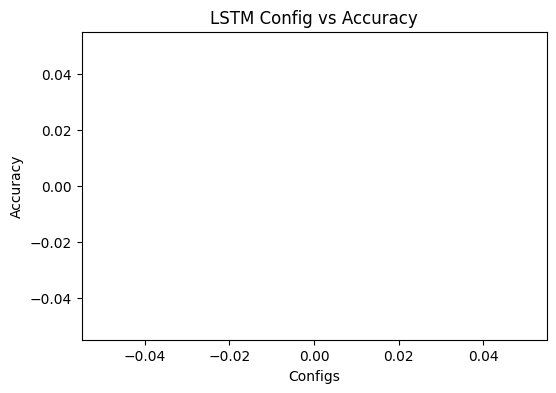

In [ ]:
labels = [f"Config {i+1}" for i in range(len(lstm_results))]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(labels, lstm_results)

plt.title("LSTM Config vs Accuracy")
plt.xlabel("Configs")
plt.ylabel("Accuracy")

for i, v in enumerate(lstm_results):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

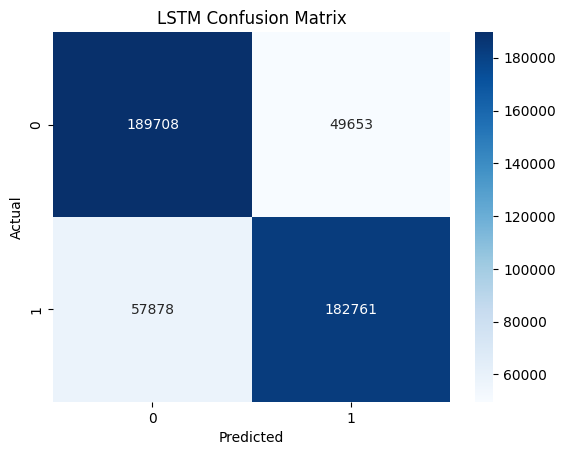

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np


y_pred = model.predict(X_test)


y_pred = (y_pred > 0.5).astype("int32")


cm = confusion_matrix(y_test, y_pred)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

In [ ]:
evaluation_parameters(y_test, y_pred)


----- Evaluation Parameters -----

Metric          Positive        Negative       
---------------------------------------------
Precision       0.7864          0.7662         
Recall          0.7595          0.7926         
F1-Score        0.7727          0.7792         

Overall Accuracy: 0.7760
